---
## SETUP: Install & Import Library

In [1]:
# Install library yang diperlukan
!pip install -q kaggle

# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

print(' Library berhasil diimport!')


[notice] A new release of pip available: 22.2.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


 Library berhasil diimport!


In [2]:
import pandas as pd

file_id = "1PVbj-pbytZIr4pWGqiHAS0mkVHGwAD1a"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

df = pd.read_csv(url)

print('Dataset berhasil dimuat!')
print(f'Shape: {df.shape}')
print(f'Kolom: {list(df.columns)}')
# Hapus kolom tidak relevan
df = df.drop(columns=['id', 'dataset'])

# Encoding kategorik
df['sex']     = df['sex'].map({'Male': 1, 'Female': 0})
df['cp']      = df['cp'].map({'typical angina': 0, 'atypical angina': 1,
                               'non-anginal': 2, 'asymptomatic': 3})
df['fbs']     = df['fbs'].map({True: 1, False: 0})
df['restecg'] = df['restecg'].map({'normal': 0, 'lv hypertrophy': 1,
                                    'st-t abnormality': 2})
df['exang']   = df['exang'].map({True: 1, False: 0})
df['slope']   = df['slope'].map({'upsloping': 0, 'flat': 1, 'downsloping': 2})
df['thal']    = df['thal'].map({'normal': 1, 'fixed defect': 2,
                                 'reversable defect': 3})

# Rename & binarisasi target
df = df.rename(columns={'thalch': 'thalach', 'num': 'target'})
df['target'] = (df['target'] > 0).astype(int)

# Hapus missing value
df = df.dropna().reset_index(drop=True)

print('Preprocessing selesai!')
print(f'Shape: {df.shape}')
print(f'Kolom: {list(df.columns)}')
print(f'Distribusi target:\n{df["target"].value_counts()}')
df.head()


Dataset berhasil dimuat!
Shape: (920, 16)
Kolom: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
Preprocessing selesai!
Shape: (299, 14)
Kolom: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Distribusi target:
target
0    160
1    139
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145.0,233.0,1.0,1.0,150.0,0.0,2.3,2.0,0.0,2.0,0
1,67,1,3,160.0,286.0,0.0,1.0,108.0,1.0,1.5,1.0,3.0,1.0,1
2,67,1,3,120.0,229.0,0.0,1.0,129.0,1.0,2.6,1.0,2.0,3.0,1
3,37,1,2,130.0,250.0,0.0,0.0,187.0,0.0,3.5,2.0,0.0,1.0,0
4,41,0,1,130.0,204.0,0.0,1.0,172.0,0.0,1.4,0.0,0.0,1.0,0


---
## 1 DATA UNDERSTANDING

In [3]:
# 1.1 Deskripsi Dataset
print('='*60)
print('DESKRIPSI DATASET: Heart Disease UCI')
print('='*60)
print(f'Jumlah Data     : {df.shape[0]} baris')
print(f'Jumlah Fitur    : {df.shape[1] - 1} fitur + 1 target')
print(f'Variabel Target : target (0 = tidak sakit, 1 = sakit jantung)')
print(f'Tujuan Prediksi : Mengklasifikasikan pasien berisiko penyakit jantung')
print()
print('DESKRIPSI FITUR:')
fitur_info = {
    'age'      : 'Usia pasien (numerik)',
    'sex'      : 'Jenis kelamin (0=perempuan, 1=laki-laki)',
    'cp'       : 'Tipe nyeri dada (0-3)',
    'trestbps' : 'Tekanan darah istirahat (numerik)',
    'chol'     : 'Kolesterol serum mg/dl (numerik)',
    'fbs'      : 'Gula darah puasa > 120mg/dl (0/1)',
    'restecg'  : 'Hasil ECG istirahat (0-2)',
    'thalach'  : 'Detak jantung maksimum (numerik)',
    'exang'    : 'Angina akibat olahraga (0/1)',
    'oldpeak'  : 'Depresi ST (numerik)',
    'slope'    : 'Kemiringan segmen ST puncak (0-2)',
    'ca'       : 'Jumlah pembuluh utama (0-3)',
    'thal'     : 'Thalassemia (1=normal, 2=fixed defect, 3=reversable)'
}
for k, v in fitur_info.items():
    print(f'  {k:12s} : {v}')

DESKRIPSI DATASET: Heart Disease UCI
Jumlah Data     : 299 baris
Jumlah Fitur    : 13 fitur + 1 target
Variabel Target : target (0 = tidak sakit, 1 = sakit jantung)
Tujuan Prediksi : Mengklasifikasikan pasien berisiko penyakit jantung

DESKRIPSI FITUR:
  age          : Usia pasien (numerik)
  sex          : Jenis kelamin (0=perempuan, 1=laki-laki)
  cp           : Tipe nyeri dada (0-3)
  trestbps     : Tekanan darah istirahat (numerik)
  chol         : Kolesterol serum mg/dl (numerik)
  fbs          : Gula darah puasa > 120mg/dl (0/1)
  restecg      : Hasil ECG istirahat (0-2)
  thalach      : Detak jantung maksimum (numerik)
  exang        : Angina akibat olahraga (0/1)
  oldpeak      : Depresi ST (numerik)
  slope        : Kemiringan segmen ST puncak (0-2)
  ca           : Jumlah pembuluh utama (0-3)
  thal         : Thalassemia (1=normal, 2=fixed defect, 3=reversable)


In [4]:
# 1.2 Tipe data & statistik deskriptif
print('TIPE DATA SETIAP KOLOM:')
print(df.dtypes)
print()
print('STATISTIK DESKRIPTIF:')
df.describe()

TIPE DATA SETIAP KOLOM:
age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

STATISTIK DESKRIPTIF:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,299.000000,299.00000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000
mean,54.521739,0.67893,2.163880,131.715719,246.785953,0.143813,0.515050,149.327759,0.331104,1.058528,0.605351,0.672241,1.842809,0.464883
std,9.030264,0.46767,0.964069,17.747751,52.532582,0.351488,0.526742,23.121062,0.471399,1.162769,0.616962,0.937438,0.958207,0.499601
min,29.000000,0.00000,0.000000,94.000000,100.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.00000,2.000000,120.000000,211.000000,0.000000,0.000000,132.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.00000,2.000000,130.000000,242.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,1.000000,0.000000
75%,61.000000,1.00000,3.000000,140.000000,275.500000,0.000000,1.000000,165.500000,1.000000,1.600000,1.000000,1.000000,3.000000,1.000000
max,77.000000,1.00000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


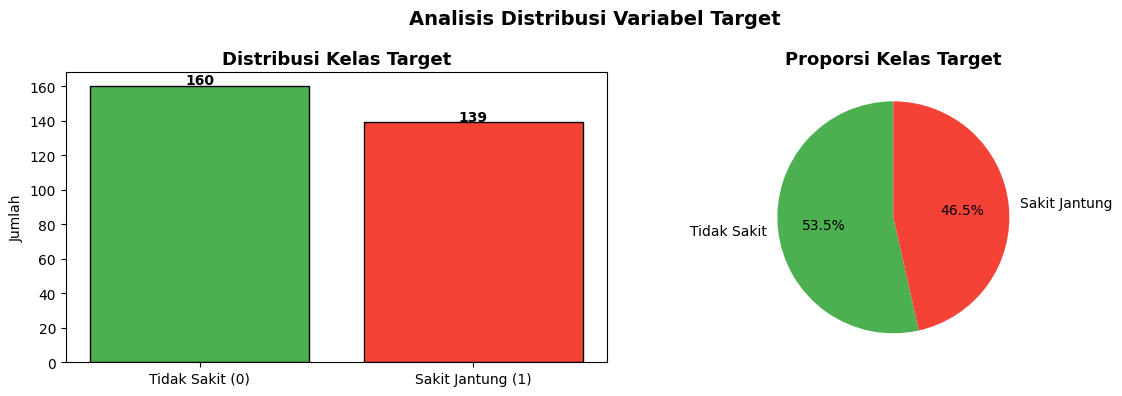

Distribusi: {0: 160, 1: 139}


In [5]:
# 1.3 Distribusi Target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
target_counts = df['target'].value_counts()
axes[0].bar(['Tidak Sakit (0)', 'Sakit Jantung (1)'],
            target_counts.values, color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_title('Distribusi Kelas Target', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['Tidak Sakit', 'Sakit Jantung'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90)
axes[1].set_title('Proporsi Kelas Target', fontsize=13, fontweight='bold')

plt.suptitle('Analisis Distribusi Variabel Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi_target.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Distribusi: {target_counts.to_dict()}')

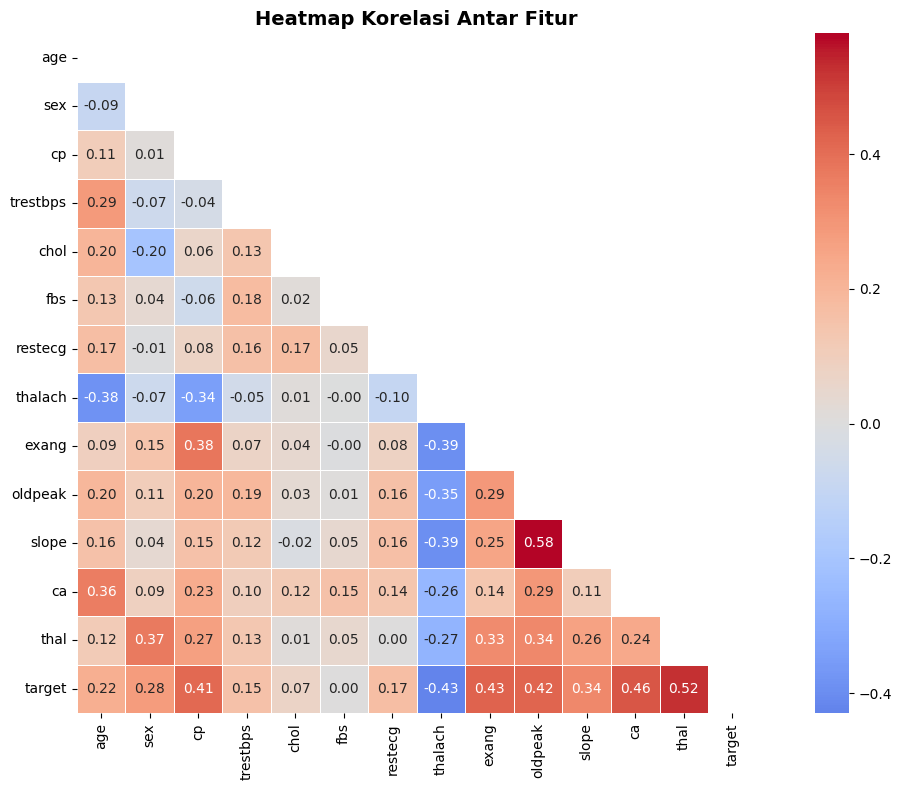

In [6]:
# 1.4 Heatmap Korelasi
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2️ DATA PREPARATION & FEATURE ENGINEERING

In [7]:
# 2.1 Cek Missing Values
print('CEK MISSING VALUES:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else '✅ Tidak ada missing value!')
print()

# 2.2 Cek Duplikat
duplikat = df.duplicated().sum()
print(f'CEK DUPLIKAT: {duplikat} baris duplikat ditemukan')
if duplikat > 0:
    df = df.drop_duplicates()
    print(f'✅ Duplikat dihapus. Shape baru: {df.shape}')
else:
    print('✅ Tidak ada duplikat!')

CEK MISSING VALUES:
✅ Tidak ada missing value!

CEK DUPLIKAT: 0 baris duplikat ditemukan
✅ Tidak ada duplikat!


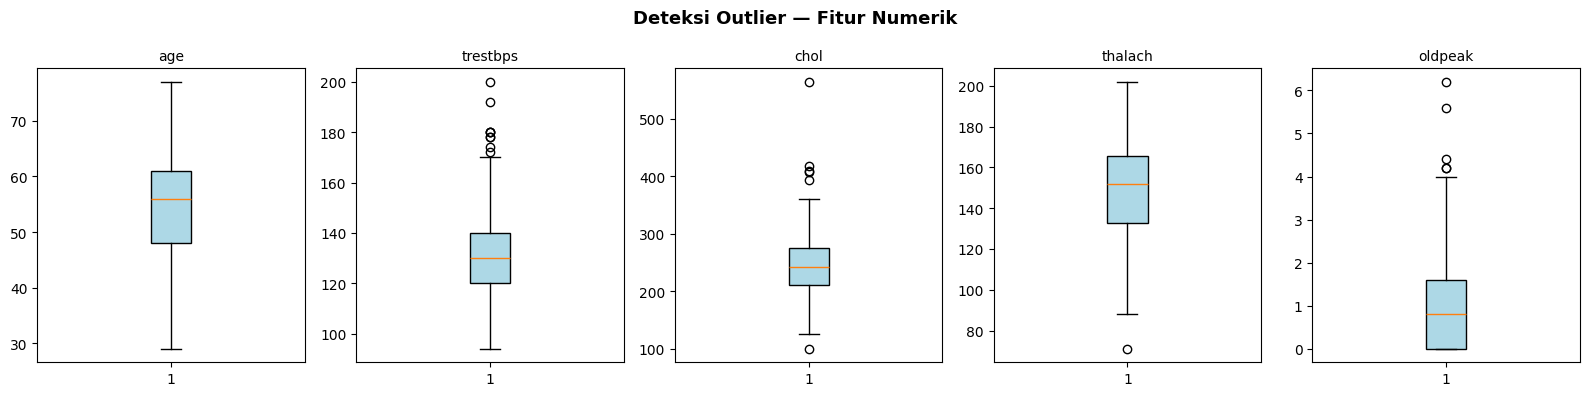

Catatan: Outlier dipertahankan karena merepresentasikan kondisi klinis nyata.


In [8]:
# 2.3 Cek Outlier dengan Boxplot
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, len(numerical_cols), figsize=(16, 4))
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                   boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Deteksi Outlier — Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outlier_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Catatan: Outlier dipertahankan karena merepresentasikan kondisi klinis nyata.')

In [9]:
# 2.4 Fitur Kategorik — Tidak perlu encoding karena sudah numerik
print('JENIS FITUR:')
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_cols   = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
print(f'  Kategorik (sudah numerik): {categorical_cols}')
print(f'  Numerik kontinyu         : {numerical_cols}')
print()

# 2.5 Pemisahan Fitur dan Target
X = df.drop('target', axis=1)
y = df['target']
print(f'Shape X (fitur) : {X.shape}')
print(f'Shape y (target): {y.shape}')

JENIS FITUR:
  Kategorik (sudah numerik): ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
  Numerik kontinyu         : ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Shape X (fitur) : (299, 13)
Shape y (target): (299,)


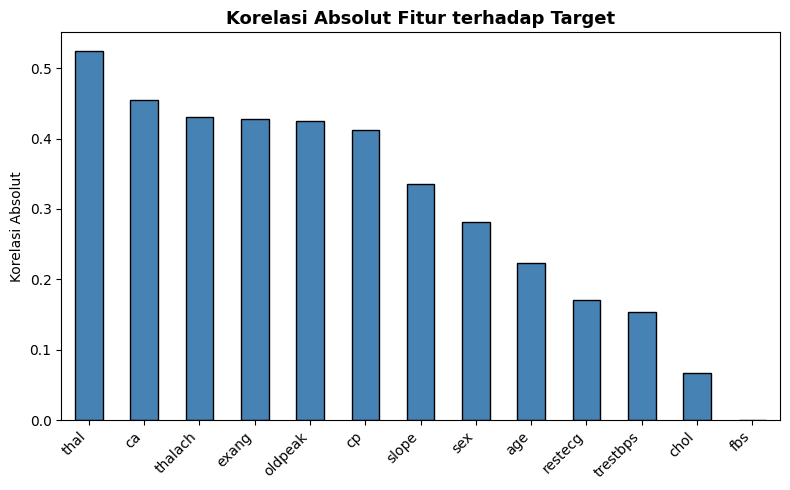

TOP 5 Fitur paling berkorelasi dengan target:
thal       0.524674
ca         0.455398
thalach    0.430108
exang      0.427123
oldpeak    0.424947
Name: target, dtype: float64


In [10]:
# 2.6 Feature Importance (sekilas dengan korelasi)
corr_target = df.corr()['target'].drop('target').abs().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
corr_target.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Korelasi Absolut Fitur terhadap Target', fontsize=13, fontweight='bold')
plt.ylabel('Korelasi Absolut')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('TOP 5 Fitur paling berkorelasi dengan target:')
print(corr_target.head())

In [11]:
# 2.7 Split Data: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Data Training : {X_train.shape[0]} sampel')
print(f'Data Testing  : {X_test.shape[0]} sampel')
print(f'Rasio         : 80% / 20%')

# 2.8 Normalisasi (untuk KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('✅ Normalisasi StandardScaler diterapkan untuk model KNN')

Data Training : 239 sampel
Data Testing  : 60 sampel
Rasio         : 80% / 20%
✅ Normalisasi StandardScaler diterapkan untuk model KNN


---
## 3️ PEMODELAN — MODEL 1: Decision Tree

In [12]:
# ============================================================
# MODEL 1: Decision Tree Classifier
# ============================================================
print('='*55)
print('MODEL 1: DECISION TREE CLASSIFIER')
print('='*55)S

# Inisialisasi & Training
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt_model.fit(X_train, y_train)

# Parameter model
print('Parameter Model:')
print(f'  max_depth        = {dt_model.max_depth}')
print(f'  min_samples_split= {dt_model.min_samples_split}')
print(f'  min_samples_leaf = {dt_model.min_samples_leaf}')
print(f'  criterion        = {dt_model.criterion}')

# Prediksi
y_pred_dt = dt_model.predict(X_test)

# Evaluasi
acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt  = recall_score(y_test, y_pred_dt)
f1_dt   = f1_score(y_test, y_pred_dt)

print(f'\nHASIL EVALUASI Decision Tree:')
print(f'  Accuracy  : {acc_dt:.4f}  ({acc_dt*100:.2f}%)')
print(f'  Precision : {prec_dt:.4f}')
print(f'  Recall    : {rec_dt:.4f}')
print(f'  F1-Score  : {f1_dt:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_dt,
                             target_names=['Tidak Sakit', 'Sakit Jantung']))

SyntaxError: invalid syntax (2855161555.py, line 6)

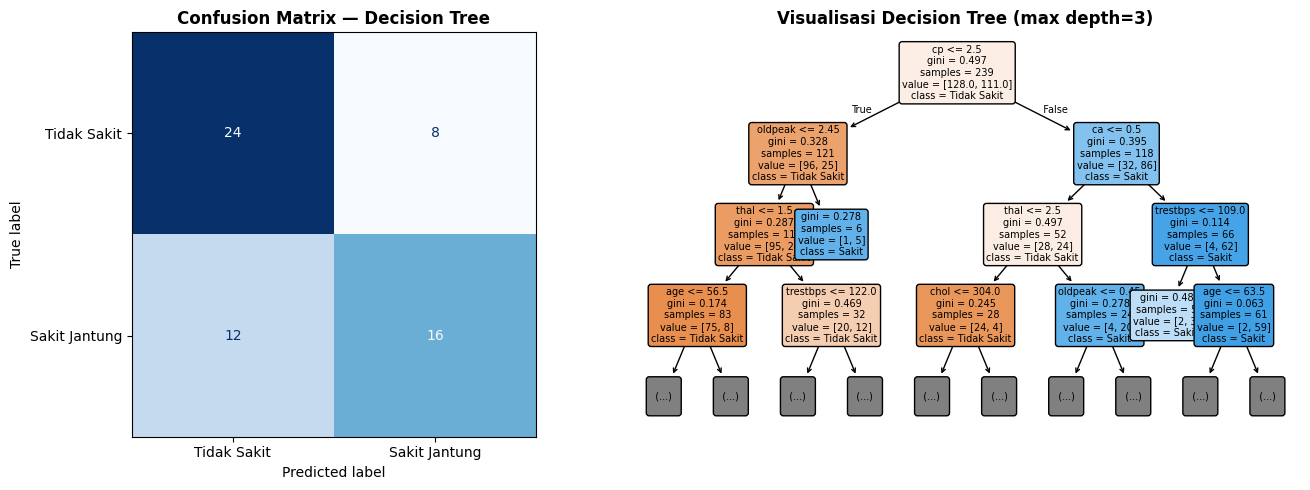

In [ ]:
# Visualisasi Confusion Matrix - Decision Tree
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(cm_dt, display_labels=['Tidak Sakit', 'Sakit Jantung'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Decision Tree', fontweight='bold')

# Visualisasi Pohon
plot_tree(dt_model, feature_names=X.columns, class_names=['Tidak Sakit','Sakit'],
          filled=True, rounded=True, max_depth=3, ax=axes[1], fontsize=7)
axes[1].set_title('Visualisasi Decision Tree (max depth=3)', fontweight='bold')

plt.tight_layout()
plt.savefig('decision_tree_hasil.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3️⃣ PEMODELAN — MODEL 2: Random Forest

In [ ]:
# ============================================================
# MODEL 2: Random Forest Classifier
# ============================================================
print('='*55)
print('MODEL 2: RANDOM FOREST CLASSIFIER')
print('='*55)

# Inisialisasi & Training
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
rf_model.fit(X_train, y_train)

print('Parameter Model:')
print(f'  n_estimators     = {rf_model.n_estimators}')
print(f'  max_depth        = {rf_model.max_depth}')
print(f'  min_samples_split= {rf_model.min_samples_split}')

# Prediksi
y_pred_rf = rf_model.predict(X_test)

# Evaluasi
acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)

print(f'\nHASIL EVALUASI Random Forest:')
print(f'  Accuracy  : {acc_rf:.4f}  ({acc_rf*100:.2f}%)')
print(f'  Precision : {prec_rf:.4f}')
print(f'  Recall    : {rec_rf:.4f}')
print(f'  F1-Score  : {f1_rf:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf,
                             target_names=['Tidak Sakit', 'Sakit Jantung']))

MODEL 2: RANDOM FOREST CLASSIFIER
Parameter Model:
  n_estimators     = 100
  max_depth        = 10
  min_samples_split= 5

HASIL EVALUASI Random Forest:
  Accuracy  : 0.8167  (81.67%)
  Precision : 0.8696
  Recall    : 0.7143
  F1-Score  : 0.7843

Classification Report:
               precision    recall  f1-score   support

  Tidak Sakit       0.78      0.91      0.84        32
Sakit Jantung       0.87      0.71      0.78        28

     accuracy                           0.82        60
    macro avg       0.83      0.81      0.81        60
 weighted avg       0.82      0.82      0.81        60



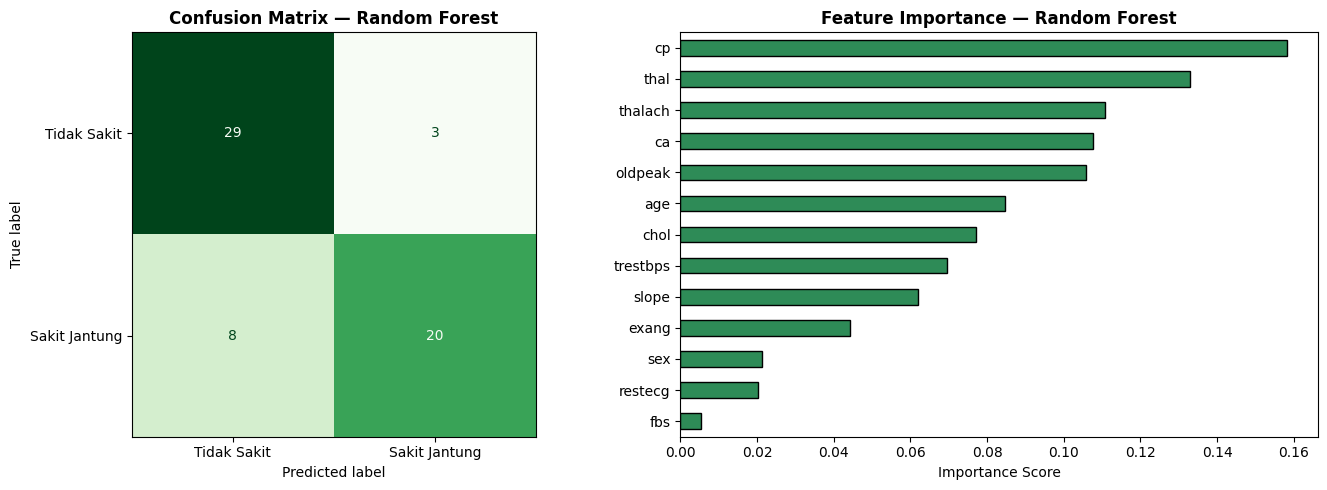

In [ ]:
# Visualisasi Confusion Matrix + Feature Importance - Random Forest
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp2 = ConfusionMatrixDisplay(cm_rf, display_labels=['Tidak Sakit', 'Sakit Jantung'])
disp2.plot(ax=axes[0], cmap='Greens', colorbar=False)
axes[0].set_title('Confusion Matrix — Random Forest', fontweight='bold')

# Feature Importance
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title('Feature Importance — Random Forest', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('random_forest_hasil.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3️ PEMODELAN — MODEL 3: K-Nearest Neighbors (KNN)

MODEL 3: K-NEAREST NEIGHBORS (KNN)
Nilai K terbaik berdasarkan Cross-Validation: K = 13


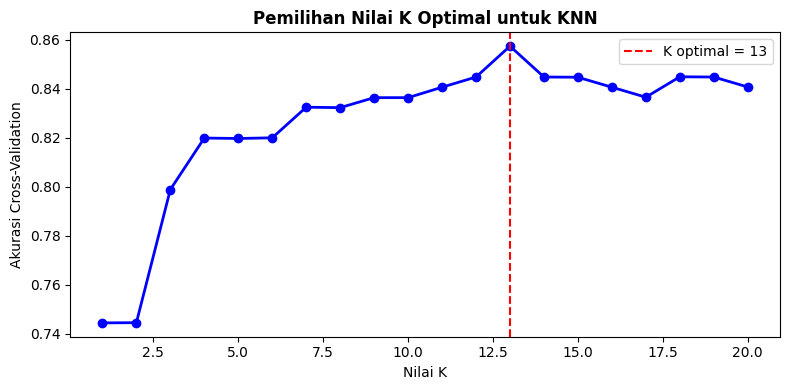


Parameter Model KNN:
  n_neighbors = 13
  metric      = euclidean

HASIL EVALUASI KNN (K=13):
  Accuracy  : 0.8500  (85.00%)
  Precision : 0.8519
  Recall    : 0.8214
  F1-Score  : 0.8364

Classification Report:
               precision    recall  f1-score   support

  Tidak Sakit       0.85      0.88      0.86        32
Sakit Jantung       0.85      0.82      0.84        28

     accuracy                           0.85        60
    macro avg       0.85      0.85      0.85        60
 weighted avg       0.85      0.85      0.85        60



In [ ]:
# ============================================================
# MODEL 3: K-Nearest Neighbors (KNN)
# ============================================================
print('='*55)
print('MODEL 3: K-NEAREST NEIGHBORS (KNN)')
print('='*55)

# Hyperparameter Tuning: Cari nilai K terbaik
k_range = range(1, 21)
k_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

best_k = k_range[np.argmax(k_scores)]
print(f'Nilai K terbaik berdasarkan Cross-Validation: K = {best_k}')

# Plot K vs Accuracy
plt.figure(figsize=(8, 4))
plt.plot(k_range, k_scores, 'bo-', linewidth=2, markersize=6)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'K optimal = {best_k}')
plt.xlabel('Nilai K')
plt.ylabel('Akurasi Cross-Validation')
plt.title('Pemilihan Nilai K Optimal untuk KNN', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# Training dengan K terbaik
knn_model = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_model.fit(X_train_scaled, y_train)

print(f'\nParameter Model KNN:')
print(f'  n_neighbors = {best_k}')
print(f'  metric      = euclidean')

# Prediksi
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluasi
acc_knn  = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn  = recall_score(y_test, y_pred_knn)
f1_knn   = f1_score(y_test, y_pred_knn)

print(f'\nHASIL EVALUASI KNN (K={best_k}):')
print(f'  Accuracy  : {acc_knn:.4f}  ({acc_knn*100:.2f}%)')
print(f'  Precision : {prec_knn:.4f}')
print(f'  Recall    : {rec_knn:.4f}')
print(f'  F1-Score  : {f1_knn:.4f}')

print('\nClassification Report:')
print(classification_report(y_test, y_pred_knn,
                             target_names=['Tidak Sakit', 'Sakit Jantung']))

<Figure size 600x500 with 0 Axes>

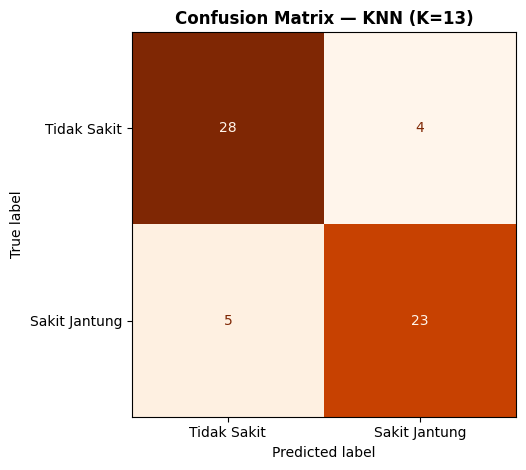

In [ ]:
# Visualisasi Confusion Matrix - KNN
plt.figure(figsize=(6, 5))
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp3 = ConfusionMatrixDisplay(cm_knn, display_labels=['Tidak Sakit', 'Sakit Jantung'])
disp3.plot(cmap='Oranges', colorbar=False)
plt.title(f'Confusion Matrix — KNN (K={best_k})', fontweight='bold')
plt.tight_layout()
plt.savefig('knn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5️ EVALUASI DAN PERBANDINGAN MODEL

In [ ]:
# ============================================================
# TABEL PERBANDINGAN PERFORMA SEMUA MODEL
# ============================================================
hasil = {
    'Model'    : ['Decision Tree', 'Random Forest', f'KNN (K={best_k})'],
    'Accuracy' : [acc_dt,  acc_rf,  acc_knn],
    'Precision': [prec_dt, prec_rf, prec_knn],
    'Recall'   : [rec_dt,  rec_rf,  rec_knn],
    'F1-Score' : [f1_dt,   f1_rf,   f1_knn]
}
df_hasil = pd.DataFrame(hasil)
df_hasil = df_hasil.set_index('Model')

# Format sebagai persen
df_tampil = df_hasil.copy()
for col in df_tampil.columns:
    df_tampil[col] = df_tampil[col].apply(lambda x: f'{x:.4f} ({x*100:.2f}%)')

print('='*70)
print('TABEL PERBANDINGAN PERFORMA MODEL')
print('='*70)
print(df_tampil.to_string())

# Tentukan model terbaik berdasarkan F1-Score
best_model_name = df_hasil['F1-Score'].idxmax()
best_f1 = df_hasil['F1-Score'].max()
print(f'\n🏆 Model Terbaik: {best_model_name} (F1-Score: {best_f1:.4f})')

TABEL PERBANDINGAN PERFORMA MODEL
                      Accuracy        Precision           Recall         F1-Score
Model                                                                            
Decision Tree  0.6667 (66.67%)  0.6667 (66.67%)  0.5714 (57.14%)  0.6154 (61.54%)
Random Forest  0.8167 (81.67%)  0.8696 (86.96%)  0.7143 (71.43%)  0.7843 (78.43%)
KNN (K=13)     0.8500 (85.00%)  0.8519 (85.19%)  0.8214 (82.14%)  0.8364 (83.64%)

🏆 Model Terbaik: KNN (K=13) (F1-Score: 0.8364)


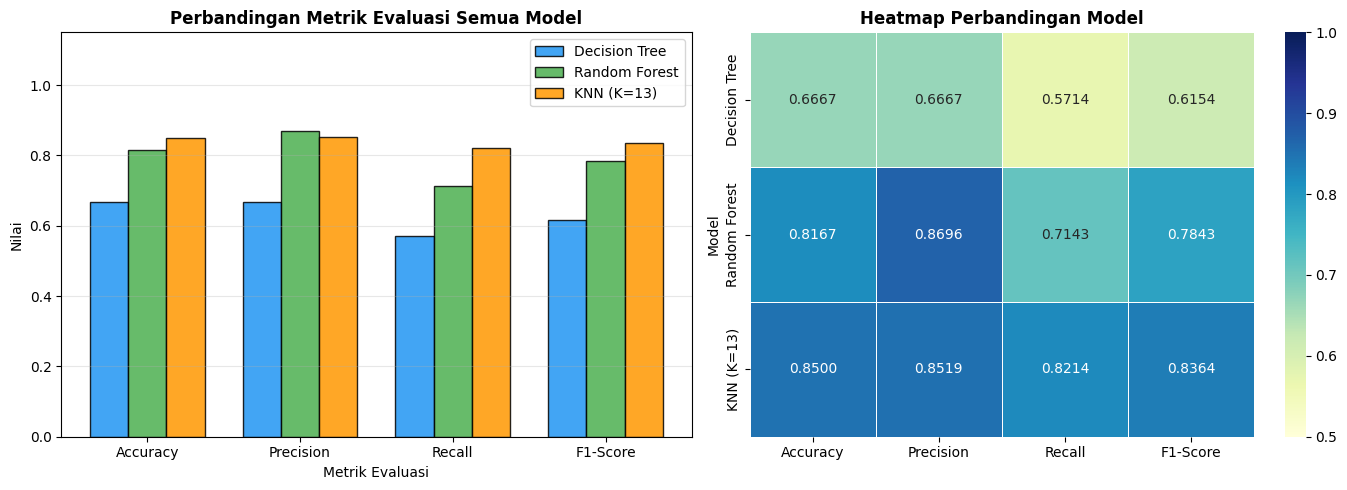

In [ ]:
# Visualisasi Perbandingan Performa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart perbandingan semua metrik
x = np.arange(len(df_hasil.columns))
width = 0.25
colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, (model, row) in enumerate(df_hasil.iterrows()):
    axes[0].bar(x + i*width, row.values, width, label=model,
                color=colors[i], edgecolor='black', alpha=0.85)

axes[0].set_xlabel('Metrik Evaluasi')
axes[0].set_ylabel('Nilai')
axes[0].set_title('Perbandingan Metrik Evaluasi Semua Model', fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(df_hasil.columns)
axes[0].set_ylim(0, 1.15)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Heatmap perbandingan
sns.heatmap(df_hasil, annot=True, fmt='.4f', cmap='YlGnBu',
            vmin=0.5, vmax=1.0, ax=axes[1], linewidths=0.5)
axes[1].set_title('Heatmap Perbandingan Model', fontweight='bold')

plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6️ ANALISIS HASIL EVALUASI

In [ ]:
# Cross-Validation untuk validasi yang lebih robust
print('='*60)
print('CROSS-VALIDATION (5-Fold) — VALIDASI TAMBAHAN')
print('='*60)

models_cv = {
    'Decision Tree' : (dt_model,  X_train,        y_train),
    'Random Forest' : (rf_model,  X_train,        y_train),
    f'KNN (K={best_k})': (knn_model, X_train_scaled, y_train)
}

cv_results = {}
for name, (model, X_tr, y_tr) in models_cv.items():
    scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:20s}: Mean={scores.mean():.4f}, Std={scores.std():.4f}, '
          f'Min={scores.min():.4f}, Max={scores.max():.4f}')

print()
print('='*60)
print('KESIMPULAN ANALISIS:')
print('='*60)
print(f'1. Model dengan akurasi tertinggi  : {df_hasil["Accuracy"].idxmax()}')
print(f'2. Model dengan F1-Score tertinggi : {df_hasil["F1-Score"].idxmax()}')
print(f'3. Model dengan Recall tertinggi   : {df_hasil["Recall"].idxmax()}')
print()
print(f'➡ Model terbaik yang direkomendasikan: {best_model_name}')
print(f'  Alasan: Pada kasus prediksi penyakit jantung, F1-Score merupakan')
print(f'  metrik yang paling relevan karena mempertimbangkan keseimbangan')
print(f'  antara Precision dan Recall.')

CROSS-VALIDATION (5-Fold) — VALIDASI TAMBAHAN
Decision Tree       : Mean=0.7449, Std=0.0416, Min=0.6667, Max=0.7872
Random Forest       : Mean=0.8283, Std=0.0821, Min=0.6875, Max=0.9167
KNN (K=13)          : Mean=0.8574, Std=0.0747, Min=0.7500, Max=0.9375

KESIMPULAN ANALISIS:
1. Model dengan akurasi tertinggi  : KNN (K=13)
2. Model dengan F1-Score tertinggi : KNN (K=13)
3. Model dengan Recall tertinggi   : KNN (K=13)

➡ Model terbaik yang direkomendasikan: KNN (K=13)
  Alasan: Pada kasus prediksi penyakit jantung, F1-Score merupakan
  metrik yang paling relevan karena mempertimbangkan keseimbangan
  antara Precision dan Recall.


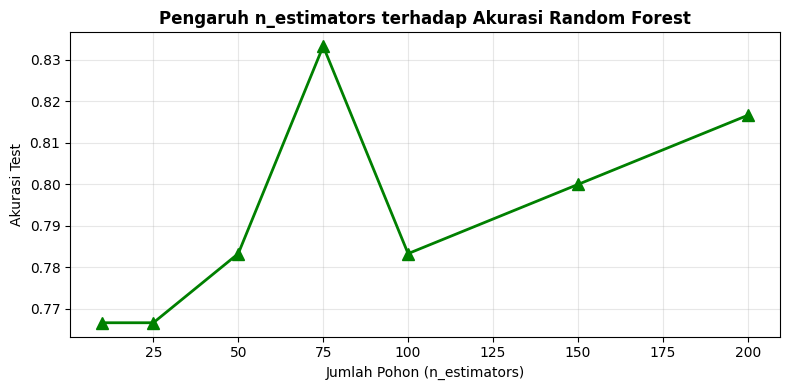

In [ ]:
# Analisis Pengaruh Hyperparameter - Random Forest (n_estimators)
n_est_range = [10, 25, 50, 75, 100, 150, 200]
acc_n_est = []

for n in n_est_range:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_temp.fit(X_train, y_train)
    acc_n_est.append(accuracy_score(y_test, rf_temp.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(n_est_range, acc_n_est, 'g^-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Pohon (n_estimators)')
plt.ylabel('Akurasi Test')
plt.title('Pengaruh n_estimators terhadap Akurasi Random Forest', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('hyperparameter_rf.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Ringkasan Akhir
print('='*65)
print('RINGKASAN EKSPERIMEN SELESAI')
print('='*65)
print(f'Dataset       : Heart Disease UCI ({df.shape[0]} sampel, {df.shape[1]-1} fitur)')
print(f'Fokus Studi   : Klasifikasi Biner')
print(f'Model Diuji   : Decision Tree | Random Forest | KNN')
print()
print('Performa Akhir:')
for m in df_hasil.index:
    r = df_hasil.loc[m]
    print(f'  {m:20s}: Acc={r["Accuracy"]:.4f} | Prec={r["Precision"]:.4f} | '
          f'Rec={r["Recall"]:.4f} | F1={r["F1-Score"]:.4f}')
print()
print(f'🏆 Model Terbaik: {best_model_name}')



RINGKASAN EKSPERIMEN SELESAI
Dataset       : Heart Disease UCI (299 sampel, 13 fitur)
Fokus Studi   : Klasifikasi Biner
Model Diuji   : Decision Tree | Random Forest | KNN

Performa Akhir:
  Decision Tree       : Acc=0.6667 | Prec=0.6667 | Rec=0.5714 | F1=0.6154
  Random Forest       : Acc=0.8167 | Prec=0.8696 | Rec=0.7143 | F1=0.7843
  KNN (K=13)          : Acc=0.8500 | Prec=0.8519 | Rec=0.8214 | F1=0.8364

🏆 Model Terbaik: KNN (K=13)
